CFL Condition

The goal here is to understand the effect of altering the number of grid point and time steps. In simple terms it's all about understanding stability.

In [11]:
# importing libraries

import numpy as np
import matplotlib.pyplot as plt


# making the whole code in a function so that it can be called from other scripts
def plot_linearconv(nx):
    # initializing the parameters
    dx  = 2 / (nx - 1)  # grid spacing
    nt = 20  # number of time steps
    dt = 0.025  # time step size
    c = 1 # wave speed

    # initializing the grid
    u = np.ones(nx)  # initialize u as an array of ones
    u[int(0.5 / dx):int(1 / dx + 1)] = 2  # set u=2 between 0.5 and 1 as the initial condition

    # initalizing a copy of u to hold the updated values
    un = np.ones(nx)

    # implemnenting the finite difference scheme
    for n in range(nt):  # loop over time steps
        un = u.copy()  # copy the existing values of u into un
        for i in range(1, nx):  # loop over spatial points
            u[i] = un[i] - c * dt / dx * (un[i] - un[i - 1])  # update u based on the finite difference scheme

    # plotting the results
    plt.plot(np.linspace(0, 2, nx), u)  # plot u

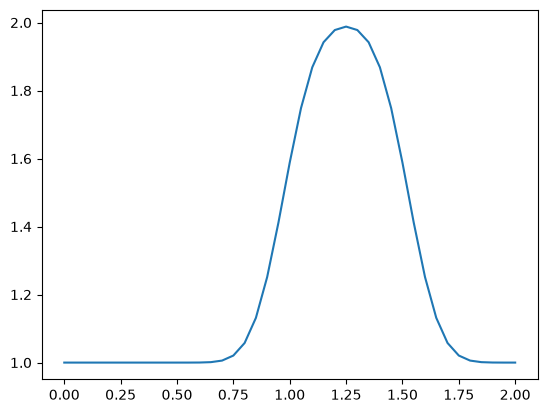

In [12]:
plot_linearconv(41)  # call the function with nx=41

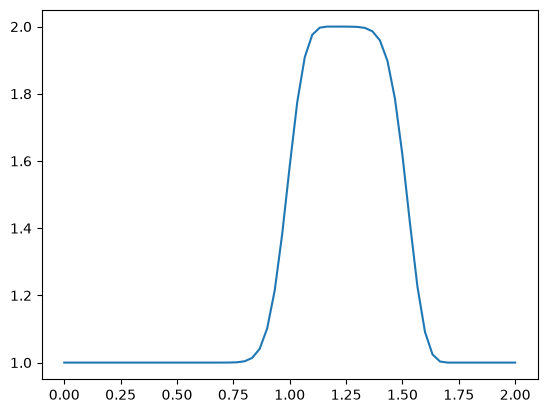

In [13]:
plot_linearconv(61)  # call the function with nx=61

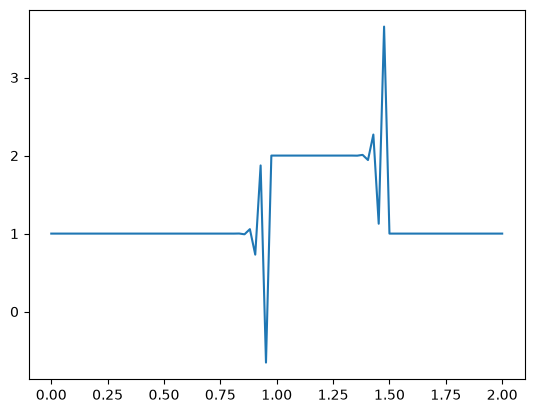

In [14]:
plot_linearconv(85)  # call the function with nx=85

What did i learn

The problem in our code is that beyond nx = 81, we start getting a result that is not expected and this is because beyond that point the given time step size (0.025 - the time at which the computer updates our solution) becomes larger than the grid point spacing (dx), therefore there wil be no values captured at some grid point and because the computer needs those values for the net iteration as stated in our finite differnce approximation, it manufuctures values for those grid points and then we get an unstable solution.


How to solve this problem: Scientist introuded the courant (CFL) number to prevent the problem; it is given as (distance travelled in one time step) / (distance between grid points)

In [15]:
# Rewriting the function to include the CFL condition and plot the results for different CFL numbers

def plot_linearconv_cfl(nx, cfl):
    # initializing the parameters
    dx  = 2 / (nx - 1)  # grid spacing
    dt = cfl * dx  # time step size based on CFL condition
    nt = 20  # number of time steps
    c = 1 # wave speed

    # initializing the grid
    u = np.ones(nx)  # initialize u as an array of ones
    u[int(0.5 / dx):int(1 / dx + 1)] = 2  # set u=2 between 0.5 and 1 as the initial condition

    # initalizing a copy of u to hold the updated values
    un = np.ones(nx)

    # implemnenting the finite difference scheme
    for n in range(nt):  # loop over time steps
        un = u.copy()  # copy the existing values of u into un
        for i in range(1, nx):  # loop over spatial points
            u[i] = un[i] - c * dt / dx * (un[i] - un[i - 1])  # update u based on the finite difference scheme

    # plotting the results
    plt.plot(np.linspace(0, 2, nx), u)  # plot u

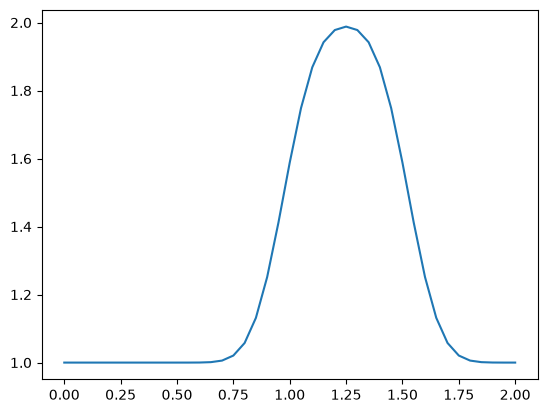

In [16]:
plot_linearconv_cfl(41, 0.5)  # call the function with nx=41 and CFL=0.5

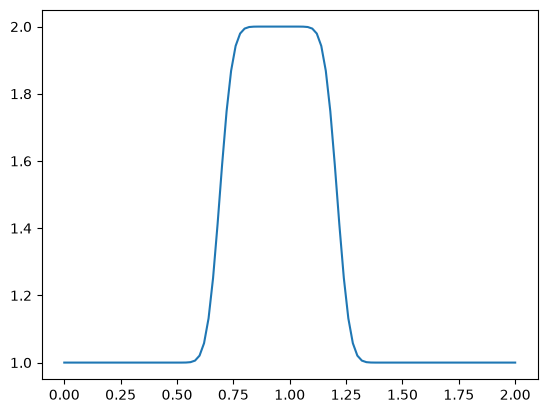

In [17]:
plot_linearconv_cfl(101, 0.5)  # call the function with nx=101 and CFL=0.5

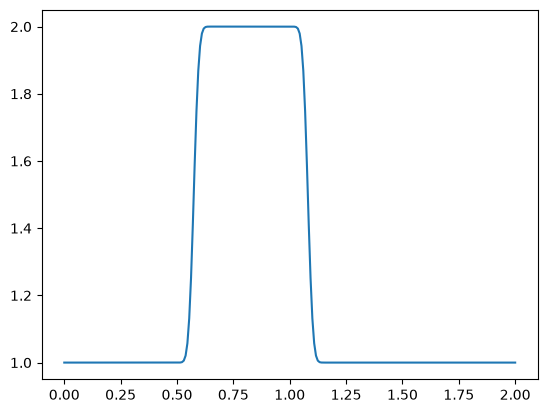

In [18]:
plot_linearconv_cfl(250, 0.5)  # call the function with nx=250 and CFL=0.5